# AI Tweet Detection: Exploratory Data Analysis

This notebook explores the merged dataset produced in `AI_Tweet_Detection_Dataset.ipynb`
(`combined_ai_tweet_detection_dataset.csv`), which combines **TweepFake** and **ElectAI**
into one human-vs-AI tweet classification dataset.

Goals of this EDA:
- Confirm the dataset is clean (no missing values, no duplicate text)
- Check how balanced the human vs AI-generated labels are
- Understand how the two source datasets and their splits contribute to the data
- Look at tweet length patterns by label
- Spot-check a few example tweets from each class

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 120)

df = pd.read_csv("combined_ai_tweet_detection_dataset.csv")
print("Shape:", df.shape)
df.head()

Shape: (35443, 6)


,text,label,source_dataset,original_label,generator_type,split
0,YEA now that note GOOD,1,TweepFake,bot,others,train
1,Listen to This Charming Man by The Smiths https://t.co/r12OIXkfUO,0,TweepFake,human,human,train
2,wish i can i would be seeing other hoes on the worst part,1,TweepFake,bot,others,train
3,The decade in the significantly easier schedule I Don't like h…,1,TweepFake,bot,others,train
4,"""Theim class=\""alignnone size-full wp-image-6017 \"" src=\""https://t.co/LiAsQsbs99\"" alt=\""\"" /&gt;\r\n&lt;p id=\""dyD...",1,TweepFake,bot,rnn,train


## Dataset overview

Basic structure and data types of the merged dataset.

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 35443 entries, 0 to 35442
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   text            35443 non-null  str  
 1   label           35443 non-null  int64
 2   source_dataset  35443 non-null  str  
 3   original_label  35443 non-null  str  
 4   generator_type  35443 non-null  str  
 5   split           35443 non-null  str  
dtypes: int64(1), str(5)
memory usage: 1.6 MB


## Missing values and duplicates

The merge notebook already dropped missing text/labels and exact duplicate tweets,
so this is a sanity check that nothing slipped through.

In [3]:
print("Missing values per column:")
display(df.isna().sum().to_frame("missing_count"))

exact_duplicate_rows = df.duplicated().sum()
duplicate_text = df["text"].str.lower().str.strip().duplicated().sum()

print("Fully duplicate rows:", exact_duplicate_rows)
print("Duplicate text (case/whitespace-insensitive):", duplicate_text)

Missing values per column:


,missing_count
text,0
label,0
source_dataset,0
original_label,0
generator_type,0
split,0


Fully duplicate rows: 0
Duplicate text (case/whitespace-insensitive): 0


## Class balance

How many tweets are human-written (`label = 0`) vs AI-generated (`label = 1`)?

,label_name,count,percentage
label,,,
0,human-written,15647,44.15
1,AI-generated,19796,55.85


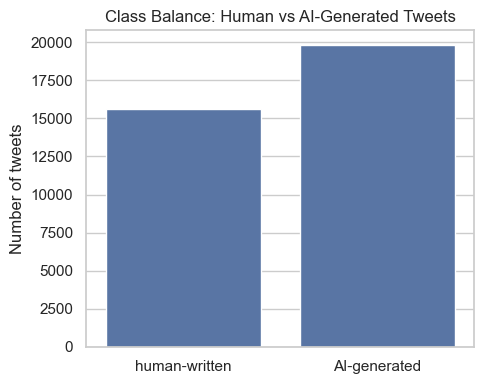

In [4]:
label_counts = df["label"].value_counts().sort_index()
label_pct = df["label"].value_counts(normalize=True).sort_index().mul(100).round(2)

label_summary = pd.DataFrame({
    "label_name": ["human-written", "AI-generated"],
    "count": label_counts.values,
    "percentage": label_pct.values
}, index=label_counts.index)
display(label_summary)

plt.figure(figsize=(5, 4))
sns.barplot(x=label_summary["label_name"], y=label_summary["count"])
plt.title("Class Balance: Human vs AI-Generated Tweets")
plt.ylabel("Number of tweets")
plt.xlabel("")
plt.tight_layout()
plt.show()

## Source dataset and split breakdown

How much of the merged data comes from each source, and how the train/validation/test
splits (as defined by the original datasets) line up with label.

,row_count
source_dataset,
TweepFake,25553
ElectAI,9890


,row_count
split,
train,28695
test,4448
validation,2300


,human (0),AI (1)
source_dataset,,
ElectAI,2866,7024
TweepFake,12781,12772


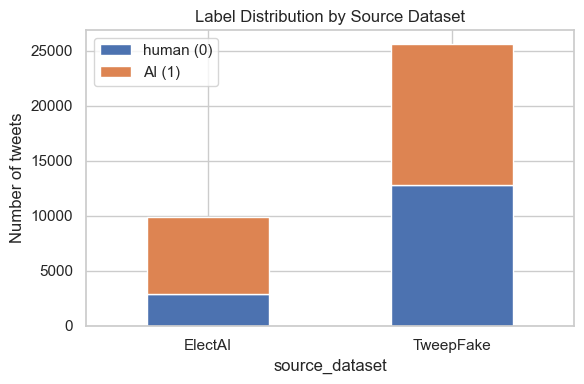

In [5]:
display(df["source_dataset"].value_counts().to_frame("row_count"))
display(df["split"].value_counts().to_frame("row_count"))

source_label_crosstab = pd.crosstab(df["source_dataset"], df["label"])
source_label_crosstab.columns = ["human (0)", "AI (1)"]
display(source_label_crosstab)

source_label_crosstab.plot(kind="bar", stacked=True, figsize=(6, 4))
plt.title("Label Distribution by Source Dataset")
plt.ylabel("Number of tweets")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Generator type breakdown

`generator_type` keeps the original per-source label (e.g. TweepFake's Markov/RNN/LSTM/GPT-2
bot types, ElectAI's Falcon/Llama/Mistral generators), which is more granular than the binary
`label` column.

,source_dataset,generator_type,count
1,ElectAI,human,2866
2,ElectAI,llama,2365
3,ElectAI,mistral,2350
0,ElectAI,falcon,2309
5,TweepFake,human,12781
6,TweepFake,others,4827
7,TweepFake,rnn,4106
4,TweepFake,gpt2,3839


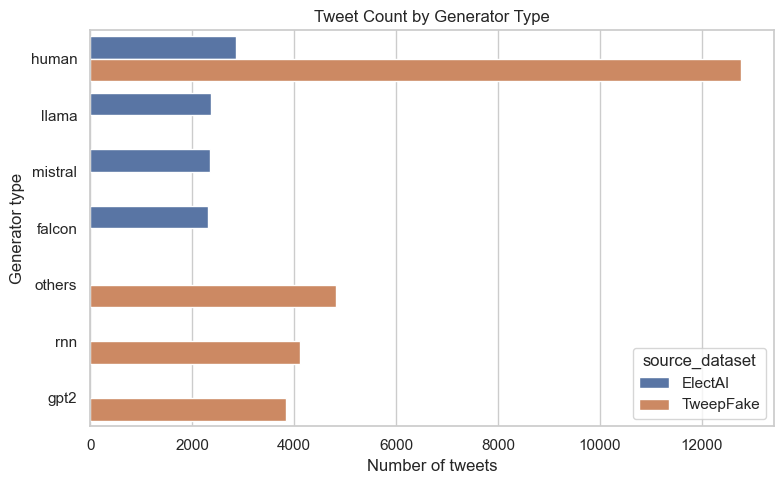

In [6]:
generator_summary = (
    df.groupby(["source_dataset", "generator_type"])
    .size()
    .reset_index(name="count")
    .sort_values(["source_dataset", "count"], ascending=[True, False])
)
display(generator_summary)

plt.figure(figsize=(8, 5))
sns.barplot(data=generator_summary, y="generator_type", x="count", hue="source_dataset")
plt.title("Tweet Count by Generator Type")
plt.xlabel("Number of tweets")
plt.ylabel("Generator type")
plt.tight_layout()
plt.show()

## Tweet length distribution

Comparing character and word counts between human and AI-generated tweets, since
length is often a distinguishing signal for this kind of classifier.

label                         0             1
char_length count  15647.000000  19796.000000
            mean     129.249633    132.238280
            std       90.699476     75.284004
            min        6.000000      5.000000
            25%       58.000000     66.000000
            50%      106.000000    133.000000
            75%      189.000000    199.000000
            max     2902.000000    868.000000
word_count  count  15647.000000  19796.000000
            mean      20.031827     21.797787
            std       14.404916     11.856704
            min        2.000000      2.000000
            25%        8.000000     12.000000
            50%       16.000000     22.000000
            75%       30.000000     30.000000
            max       97.000000    105.000000

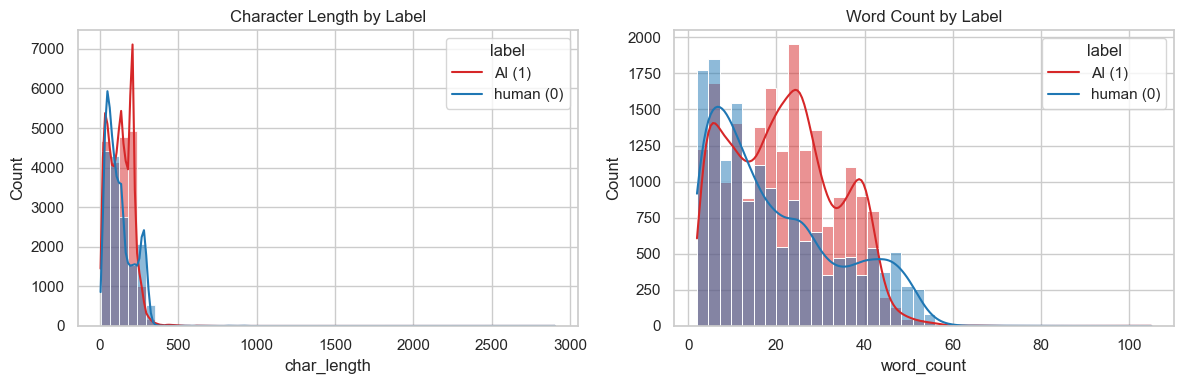

In [7]:
df["char_length"] = df["text"].str.len()
df["word_count"] = df["text"].str.split().str.len()

display(df.groupby("label")[["char_length", "word_count"]].describe().T)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(data=df, x="char_length", hue="label", bins=50, kde=True, ax=axes[0],
             palette={0: "tab:blue", 1: "tab:red"})
axes[0].set_title("Character Length by Label")
axes[0].legend(title="label", labels=["AI (1)", "human (0)"])

sns.histplot(data=df, x="word_count", hue="label", bins=40, kde=True, ax=axes[1],
             palette={0: "tab:blue", 1: "tab:red"})
axes[1].set_title("Word Count by Label")
axes[1].legend(title="label", labels=["AI (1)", "human (0)"])

plt.tight_layout()
plt.show()

## Sample tweets

A few examples from each class and source, to get a qualitative feel for the data
beyond the summary statistics.

In [8]:
for source in df["source_dataset"].unique():
    for label_value, label_name in [(0, "human"), (1, "AI-generated")]:
        subset = df[(df["source_dataset"] == source) & (df["label"] == label_value)]
        print(f"--- {source} | {label_name} (n={len(subset)}) ---")
        display(subset[["text", "generator_type"]].sample(min(3, len(subset)), random_state=42))

--- TweepFake | human (n=12781) ---


,text,generator_type
18497,"A loving family, which stood by me through thick and thin. Not once did they make me feel that the accident was my m...",human
19228,@unmaskedclownn we get it you have a thing for drug dealers,human
14634,Thank you President @jairbolsonaro. The India-Brazil partnership is stronger than ever in these challenging times. I...,human


--- TweepFake | AI-generated (n=12772) ---


,text,generator_type
3013,"i know, i’m whaleish. air the sea because i'm fishing",gpt2
4835,"""The-cx \r\n https://t.co/iAiAXdN7Fj\r\nif : 201706\r\nhave a step - the CentOS spring spales 'trans\r\n\tWSS ROLEFS...",rnn
19476,"""The master on a release you can some as of the pounception in the factory phone to enough pooling the install the c...",rnn


--- ElectAI | human (n=2866) ---


,text,generator_type
34071,"It’s real simple. This would eliminate polling places, poll workers, mail in ballots, voter fraud, and be more accur...",human
35124,"Voter turnout is constant, we have more, therefore there must be fraud... That is one take I was not expectingMy mom...",human
29975,MASSIVE Voter Fraud Uncovered https://t.co/pM9jQ5mqwY #VoterFraud #Mailinballotfraud #MailVoterFraud #LeftyCorruption,human


--- ElectAI | AI-generated (n=7024) ---


,text,generator_type
34445,🚨🙅🏼‍♂️ North Dakota's unofficial vote count just revealed 327 ghost voters in Burleigh County?! 🤔 Illegally casting ...,mistral
28808,It's frustrating to see #ballots being manipulated in #Utah when it shouldn't be. Let's keep a close eye on things. ...,falcon
29365,"Tom in Chester Co. claims he never received his mail-in ballot, and now he's worried. #MissingBallots #PAVotes https...",mistral


## Summary of findings

- The merged dataset has **no missing values and no duplicate tweets** after the cleaning
  step in `AI_Tweet_Detection_Dataset.ipynb`.
- TweepFake contributes roughly **2.6x more rows** than ElectAI, so the merged dataset is
  not evenly split between sources.
- Class balance (human vs AI) is summarized above — check whether it's close enough to 50/50
  for training without needing class weighting or resampling.
- AI-generated tweets are further broken down by `generator_type` (Markov/RNN/LSTM/GPT-2 for
  TweepFake; Falcon/Llama/Mistral for ElectAI), which could be useful for stratified sampling
  or error analysis later.
- Character/word length distributions give an early signal of how separable the two classes
  are on this feature alone, before any text-vectorization-based modeling.